<a href="https://colab.research.google.com/github/kvssri/online-tihiitg/blob/main/Controlled%20Hyperparameter%20/%20Parameter%20Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Underwater-Image-Data-set-main.zip to Underwater-Image-Data-set-main.zip


In [3]:
import zipfile
import os
import glob
import pandas as pd
import numpy as np

zip_file = list(uploaded.keys())[0]

extract_path = "/content/underwater_data"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

csv_files = glob.glob(
    extract_path + "/**/*.csv",
    recursive=True
)

print("CSV files found:", len(csv_files))

for f in csv_files:
    print(f)

CSV files found: 8
/content/underwater_data/Underwater-Image-Data-set-main/training_log 6.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 4.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 7.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 3.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 2.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 1.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 5.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 8.csv


In [4]:
all_logs = []

for f in csv_files:
    temp = pd.read_csv(f)
    temp["source_file"] = os.path.basename(f)
    all_logs.append(temp)

df = pd.concat(
    all_logs,
    ignore_index=True
)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset shape: (24915, 6)
Columns: ['epoch', 'step', 'gen_total', 'disc_loss', 'time_s', 'source_file']


In [5]:
features = [
    "epoch",
    "step",
    "disc_loss",
    "time_s"
]

target = "gen_total"

X = df[features].values
y = df[target].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (24915, 4)
y shape: (24915,)


In [6]:
SEQUENCE_LENGTH = 10

X_seq = []
y_seq = []

for i in range(len(X) - SEQUENCE_LENGTH):

    X_seq.append(
        X[i:i+SEQUENCE_LENGTH]
    )

    y_seq.append(
        y[i+SEQUENCE_LENGTH]
    )

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Sequence input:", X_seq.shape)
print("Sequence target:", y_seq.shape)

Sequence input: (24905, 10, 4)
Sequence target: (24905,)


In [7]:
n = len(X_seq)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train = X_seq[:train_end]
y_train = y_seq[:train_end]

X_val = X_seq[train_end:val_end]
y_val = y_seq[train_end:val_end]

X_test = X_seq[val_end:]
y_test = y_seq[val_end:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (17433, 10, 4)
Validation: (3736, 10, 4)
Test: (3736, 10, 4)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_2d = X_train.reshape(-1, X_train.shape[-1])

scaler.fit(X_train_2d)

# Transform all splits
X_train = scaler.transform(
    X_train_2d
).reshape(X_train.shape)

X_val = scaler.transform(
    X_val.reshape(-1, X_val.shape[-1])
).reshape(X_val.shape)

X_test = scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

print("Training-only normalization completed")

Training-only normalization completed


In [9]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
).unsqueeze(1)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
).unsqueeze(1)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
).unsqueeze(1)

In [10]:
def create_loaders(batch_size):

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    val_dataset = TensorDataset(
        X_val_tensor,
        y_val_tensor
    )

    test_dataset = TensorDataset(
        X_test_tensor,
        y_test_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader, test_loader

In [11]:
class TCNModel(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_channels=64,
        dropout=0.0
    ):

        super().__init__()

        self.network = nn.Sequential(

            nn.Conv1d(
                input_size,
                hidden_channels,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Conv1d(
                hidden_channels,
                hidden_channels,
                kernel_size=3,
                padding=2,
                dilation=2
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Conv1d(
                hidden_channels,
                32,
                kernel_size=3,
                padding=4,
                dilation=4
            ),

            nn.ReLU()
        )

        self.fc = nn.Linear(32, 1)

    def forward(self, x):

        x = x.transpose(1, 2)

        x = self.network(x)

        x = x[:, :, -1]

        return self.fc(x)

In [12]:
import time

def run_experiment(
    hidden_channels,
    dropout,
    learning_rate,
    batch_size,
    epochs=15
):

    train_loader, val_loader, _ = create_loaders(
        batch_size
    )

    model = TCNModel(
        input_size=X_train.shape[2],
        hidden_channels=hidden_channels,
        dropout=dropout
    )

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    best_val_loss = float("inf")

    train_history = []
    val_history = []

    start = time.time()

    for epoch in range(epochs):

        # Training
        model.train()

        total_train_loss = 0

        for xb, yb in train_loader:

            optimizer.zero_grad()

            pred = model(xb)

            loss = criterion(pred, yb)

            loss.backward()

            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = (
            total_train_loss /
            len(train_loader)
        )

        # Validation
        model.eval()

        total_val_loss = 0

        with torch.no_grad():

            for xb, yb in val_loader:

                pred = model(xb)

                loss = criterion(pred, yb)

                total_val_loss += loss.item()

        avg_val_loss = (
            total_val_loss /
            len(val_loader)
        )

        train_history.append(avg_train_loss)
        val_history.append(avg_val_loss)

        if avg_val_loss < best_val_loss:

            best_val_loss = avg_val_loss

    runtime = time.time() - start

    parameters = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    return {
        "model": model,
        "best_val_loss": best_val_loss,
        "train_history": train_history,
        "val_history": val_history,
        "runtime": runtime,
        "parameters": parameters
    }

In [13]:
experiments = [
    {
        "name": "TCN-1",
        "hidden_channels": 32,
        "dropout": 0.0,
        "learning_rate": 0.001,
        "batch_size": 32
    },

    {
        "name": "TCN-2",
        "hidden_channels": 64,
        "dropout": 0.0,
        "learning_rate": 0.001,
        "batch_size": 32
    },

    {
        "name": "TCN-3",
        "hidden_channels": 64,
        "dropout": 0.2,
        "learning_rate": 0.001,
        "batch_size": 32
    },

    {
        "name": "TCN-4",
        "hidden_channels": 64,
        "dropout": 0.0,
        "learning_rate": 0.0005,
        "batch_size": 32
    },

    {
        "name": "TCN-5",
        "hidden_channels": 64,
        "dropout": 0.0,
        "learning_rate": 0.001,
        "batch_size": 64
    }
]

results = []

trained_models = {}

for exp in experiments:

    print("\nRunning:", exp["name"])

    result = run_experiment(
        hidden_channels=exp["hidden_channels"],
        dropout=exp["dropout"],
        learning_rate=exp["learning_rate"],
        batch_size=exp["batch_size"],
        epochs=15
    )

    trained_models[exp["name"]] = result

    results.append({
        "Experiment": exp["name"],
        "Hidden_Channels": exp["hidden_channels"],
        "Dropout": exp["dropout"],
        "Learning_Rate": exp["learning_rate"],
        "Batch_Size": exp["batch_size"],
        "Best_Validation_Loss": result["best_val_loss"],
        "Runtime_sec": result["runtime"],
        "Parameters": result["parameters"]
    })

experiment_log = pd.DataFrame(results)

display(experiment_log)


Running: TCN-1

Running: TCN-2

Running: TCN-3

Running: TCN-4

Running: TCN-5


,Experiment,Hidden_Channels,Dropout,Learning_Rate,Batch_Size,Best_Validation_Loss,Runtime_sec,Parameters
0,TCN-1,32,0.0,0.0010,32,24.063780,41.918574,6657
1,TCN-2,64,0.0,0.0010,32,30.001929,49.108495,19393
2,TCN-3,64,0.2,0.0010,32,26.201286,56.512336,19393
3,TCN-4,64,0.0,0.0005,32,22.040364,48.405819,19393
4,TCN-5,64,0.0,0.0010,64,28.911753,33.965333,19393


In [14]:
best_index = experiment_log[
    "Best_Validation_Loss"
].idxmin()

best_experiment = experiment_log.loc[
    best_index
]

print("===== BEST VALIDATED CONFIGURATION =====")
display(best_experiment)

===== BEST VALIDATED CONFIGURATION =====


,3
Experiment,TCN-4
Hidden_Channels,64
Dropout,0.0
Learning_Rate,0.0005
Batch_Size,32
Best_Validation_Loss,22.040364
Runtime_sec,48.405819
Parameters,19393


In [15]:
best_name = best_experiment["Experiment"]

best_model = trained_models[best_name]["model"]

torch.save(
    best_model.state_dict(),
    "/content/best_tuned_tcn.pth"
)

print(
    "Best tuned checkpoint saved:",
    "/content/best_tuned_tcn.pth"
)

Best tuned checkpoint saved: /content/best_tuned_tcn.pth


In [16]:
experiment_log.to_csv(
    "/content/day19_experiment_log.csv",
    index=False
)

print("Experiment log saved successfully!")

Experiment log saved successfully!


In [18]:
import matplotlib.pyplot as plt

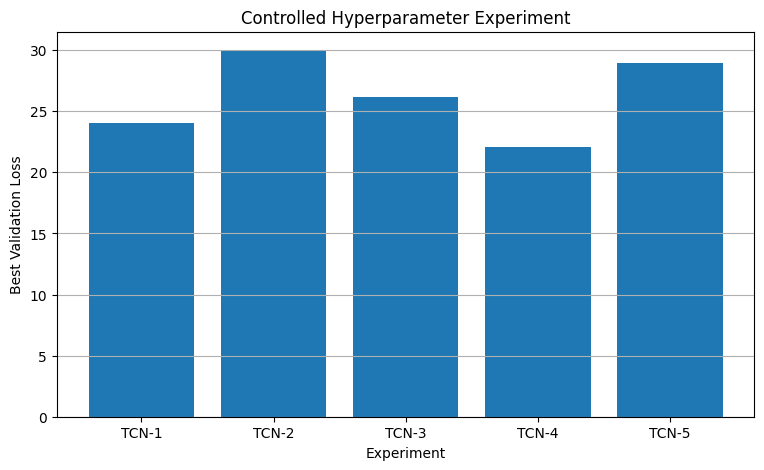

In [19]:
plt.figure(figsize=(9,5))

plt.bar(
    experiment_log["Experiment"],
    experiment_log["Best_Validation_Loss"]
)

plt.xlabel("Experiment")
plt.ylabel("Best Validation Loss")
plt.title("Controlled Hyperparameter Experiment")
plt.grid(axis="y")

plt.show()

In [20]:
import json

best_config = {
    "model": "TCN",
    "target": "gen_total",
    "sequence_length": 10,
    "hidden_channels": int(best_experiment["Hidden_Channels"]),
    "dropout": float(best_experiment["Dropout"]),
    "learning_rate": float(best_experiment["Learning_Rate"]),
    "batch_size": int(best_experiment["Batch_Size"]),
    "best_validation_loss": float(best_experiment["Best_Validation_Loss"])
}

with open("/content/best_tuned_configuration.json", "w") as f:
    json.dump(best_config, f, indent=4)

print("Best configuration saved successfully!")
print(best_config)

Best configuration saved successfully!
{'model': 'TCN', 'target': 'gen_total', 'sequence_length': 10, 'hidden_channels': 64, 'dropout': 0.0, 'learning_rate': 0.0005, 'batch_size': 32, 'best_validation_loss': 22.040363584828174}


# Day 19 – Controlled Hyperparameter / Parameter Experiments

## Objective
A controlled hyperparameter search was performed on the shortlisted TCN model.

## Experiments
The following parameters were systematically varied:
- Hidden channels
- Dropout
- Learning rate
- Batch size

## Selection Strategy
- Validation loss was used to select the best configuration.
- The test set was kept untouched during hyperparameter selection.
- All experiments were recorded in an experiment log.

## Final Outputs
- Best tuned TCN checkpoint: `best_tuned_tcn.pth`
- Experiment log: `day19_experiment_log.csv`
- Best configuration: `best_tuned_configuration.json`

## Dataset and Target
The available dataset contains underwater GAN training logs.
The prediction target used in this adapted experiment is `gen_total`.

**Note:** This is an adapted time-series experiment and is not an SoH/RUL experiment because the available dataset does not contain SoH or RUL labels.

## Outcome
The best validated TCN configuration was selected based on minimum validation loss and saved for the next stage.